In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import string
home_path = '/gws/ssde/j25a/duicv/yuansun/'

In [2]:
df_aadt_result = pd.read_csv('data_for_figure/UK-Manchester_results.csv')
df_aadt_result['factor_label'] = df_aadt_result['factor_label'].fillna('')
df_aadt_result

,period,TSA_U,RH2M,TRAFFICFLUX,factor,factor_label
0,summer,21.437250,74.060966,16.253613,base,
1,summer,21.327692,74.755310,3.250720,sub0.8,-80%
2,summer,21.386346,74.399185,9.752160,sub0.4,-40%
3,summer,21.413965,74.232178,13.002880,sub0.2,-20%
4,summer,21.426630,74.135902,14.628241,sub0.1,-10%
...,...,...,...,...,...,...
145,winter,-0.200598,85.149681,13.677839,0.1,-20%
146,winter,-0.216895,85.267159,12.195906,0.15,-30%
147,winter,-0.233466,85.405495,10.713970,0.2,-40%
148,winter,-0.252203,85.501892,9.232037,0.25,-50%


In [3]:
period_list = ['summer', 'winter'] 
factor_list2= ['0.05', '0.1', '0.15', '0.2', '0.25', '0.3']
unit_list = ['°C', '%']
labelcolor = '#6b6b6b'
xwidth = 0.5
marker_size = ['o', '*']
markersize = [2, 4]
lc1 = '#e41a1c'
lc2 = '#377eb8'
handletextpad = 0.1
labelfont = 6
textcolor = '#000000'
pad = 1
length = 2
linewidth = 0.5
title_list = [r'$\delta T_\mathrm{air}$', r'$\delta$RH']
padding = 4

Correlation between TRAFFICFLUX and TSA_U for summer: 0.9995
Correlation between TRAFFICFLUX and RH2M for summer: -0.9990
Correlation between TRAFFICFLUX and TSA_U for winter: 0.9983
Correlation between TRAFFICFLUX and RH2M for winter: -0.9959


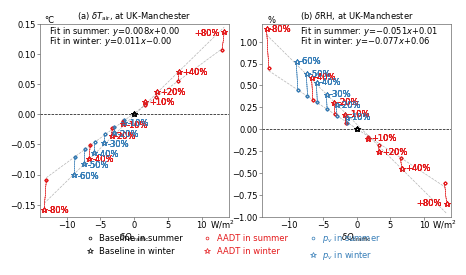

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(4.5, 2.5))
ax = ax.flatten()
vars_to_plot = ['TSA_U', 'RH2M']
for p, period in enumerate(period_list):
    df_plot = df_aadt_result[df_aadt_result['period'] == period].copy()
    # Normalize relative to base
    df_base = df_plot[df_plot['factor'] == 'base']
    df_plot['TRAFFICFLUX'] = df_plot['TRAFFICFLUX'] - df_base['TRAFFICFLUX'].values[0]
    marker = marker_size[p]
    for i, var in enumerate(vars_to_plot):
        df_plot[var] = df_plot[var] - df_base[var].values[0]
        # ---- Scatter plot with conditional markers ----
        for idx, row in df_plot.iterrows():
            factor = row['factor']
            color_style = (lc2 if factor in factor_list2 
               else textcolor if factor == 'base' 
               else lc1)
            label_style = (r'$p_{v}$' if factor in factor_list2 
               else 'Baseline' if factor == 'base' 
               else 'AADT')
            if idx in [0, 1, 9, 15, 16, 24]:
                lbl = f'{label_style} in {period}'
            else:
                lbl = None    
            ax[i].plot(row['TRAFFICFLUX'],
                       row[var],
                       marker=marker,
                       color=color_style,
                       markersize=markersize[p],
                       linestyle='none',
                       label= lbl,
                       markerfacecolor='none',
                       markeredgewidth=linewidth)
            if p ==1:
                if i ==0:
                    y_offset = -0.005
                else:
                    y_offset = -0.025 
                if row['factor'] in ['add0.8']:
                    x_offset = -4.5
                else:
                    x_offset = 0.5
                ax[i].text(row['TRAFFICFLUX']+x_offset, row[var]+y_offset, f'{row["factor_label"]}', fontsize=labelfont, color=color_style)
        # ---- Correlation ----
        cor = df_plot['TRAFFICFLUX'].corr(df_plot[var])
        print(f"Correlation between TRAFFICFLUX and {var} for {period}: {cor:.4f}")

        # ---- Regression Line ----
        x = df_plot['TRAFFICFLUX'].values
        y = df_plot[var].values
        m, b = np.polyfit(x, y, 1)

        # For smooth regression line
        x_sorted = np.linspace(x.min(), x.max(), 50)
        ax[i].plot(x_sorted, m*x_sorted + b, color = labelcolor, alpha=0.5,
                   linestyle='--', linewidth=linewidth)
        if i ==0:
            text_xloc = 0.05
        else: 
            text_xloc = 0.2  
        if b>0:
            link = r'$+$'    
        else:
            link  = r'$-$'
        if m>0:
            sign = ''    
        else:
            sign = r'$-$'    
        ax[i].text(text_xloc, 0.95-p*0.05, f'Fit in {period}: ' + r'$y$' + f'=' + f'{sign}' + f'{np.abs(m):.3f}' + r'$x$' + f'{link}' + f'{np.abs(b):.2f}', fontsize=labelfont, color=textcolor, 
                   transform=ax[i].transAxes)
        #for q in df_plot['TRAFFICFLUX']:
            #ax[i].axvline(q, color='red', linestyle=':', linewidth=0.8) # vertical

for i, var in enumerate(vars_to_plot):
    df_summer = df_aadt_result[df_aadt_result['period']=='summer'].copy()
    df_summer_base = df_summer[df_summer['factor']=='base']
    df_summer[f'{var}_delta'] = df_summer[f'{var}'] - df_summer_base[f'{var}'].values[0]
    df_summer['TRAFFICFLUX_delta'] = df_summer['TRAFFICFLUX'] - df_summer_base['TRAFFICFLUX'].values[0]
    df_winter = df_aadt_result[df_aadt_result['period']=='winter'].copy()
    df_winter_base = df_winter[df_winter['factor']=='base']
    df_winter[f'{var}_delta'] = df_winter[f'{var}'] - df_winter_base[f'{var}'].values[0]
    df_winter['TRAFFICFLUX_delta'] = df_winter['TRAFFICFLUX'] - df_winter_base['TRAFFICFLUX'].values[0]
    # pair summer and winter
    for idx in range(len(df_summer)):
        x = [df_summer['TRAFFICFLUX_delta'].iloc[idx], df_winter['TRAFFICFLUX_delta'].iloc[idx]]
        y = [df_summer[f'{var}_delta'].iloc[idx], df_winter[f'{var}_delta'].iloc[idx]]
        factor = df_summer['factor'].iloc[idx]
        if factor in factor_list2:
            color = lc2
        elif factor == 'base':
            color = textcolor
        else:
            color = lc1
        ax[i].plot(x, y, color=color, linestyle='--', linewidth=linewidth/2)
    ax[i].tick_params(axis='y', which='both', left=True, right=False, labelleft=True, labelcolor=textcolor, color=labelcolor,
                      labelsize=labelfont,pad=pad, width = xwidth, length = length)
    ax[i].tick_params(axis='x', which='both', top=False, bottom=True, labelbottom=True, labelcolor=textcolor,color=labelcolor,
                      labelsize=labelfont,pad=pad, width = xwidth, length = length)
    ax[i].set_xlabel(r"$\delta Q_\mathrm{traffic}$", fontsize=labelfont, color=textcolor, labelpad=pad)
    ax[i].set_ylabel(f"{unit_list[i]}", rotation=0, fontsize=labelfont, color=textcolor)
    ax[i].yaxis.set_label_coords(0.05, 1)
    ax[i].axhline(0, color=textcolor, linewidth=linewidth, linestyle='--')
    #ax[i].axvline(0, color=textcolor, linewidth=linewidth, linestyle='--')
    #ax[i].grid(True,linestyle='--',linewidth=0.5, alpha=0.5)
    title = f'({string.ascii_lowercase[i]}) {title_list[i]}, at UK-Manchester'
    ax[i].set_title(title, fontsize=labelfont, color=textcolor, pad=padding)
    ax[i].text(0.9, -0.0585, 'W/m$^2$', fontsize=labelfont, color=textcolor, transform=ax[i].transAxes)
    if i==0:
        ax[i].set_ylim(-0.17, 0.15)
    else:
        ax[i].set_ylim(-1, 1.2)    
    for s, spine in enumerate(ax[i].spines.values()):
        spine.set_linewidth(xwidth)
        spine.set_edgecolor(labelcolor)
    ax[i].set_xlim(-14, 14)    
lines, labels = ax[0].get_legend_handles_labels()
new_order = [0, 3, 1, 4, 2, 5]  
lines = [lines[i] for i in new_order]
labels = [labels[i] for i in new_order]
legend = fig.legend(lines, labels, bbox_to_anchor=(0.5, -0.03), loc='lower center', frameon=False, 
                    handletextpad=handletextpad, fontsize=labelfont, ncol=3)
for i, text in enumerate(legend.get_texts()):
    text.set_color(([textcolor, lc1, lc2])[i//2])
plt.subplots_adjust(left=0.075, right=0.99, bottom=0.18, top=0.95, wspace=0.175, hspace= 0.35)
fig.savefig(f'correlation.png', dpi=300)  
fig.savefig(f'correlation.pdf', dpi=600)     

# Description

In [162]:
df_result_summer = df_aadt_result[df_aadt_result['period']=='summer'].copy()
df_result_summer_base = df_result_summer[df_result_summer['factor']=='base']
df_result_summer['TSA_U_delta'] = df_result_summer['TSA_U'] - df_result_summer_base['TSA_U'].values[0]
df_result_summer


,period,TSA_U,RH2M,TRAFFICFLUX,factor,factor_label,TSA_U_delta
0,summer,21.437250,74.060966,16.253613,base,,0.000000
1,summer,21.327692,74.755310,3.250720,sub0.8,-80%,-0.109558
2,summer,21.386346,74.399185,9.752160,sub0.4,-40%,-0.050903
3,summer,21.413965,74.232178,13.002880,sub0.2,-20%,-0.023285
4,summer,21.426630,74.135902,14.628241,sub0.1,-10%,-0.010620
5,summer,21.452600,73.966049,17.878962,add0.1,+10%,0.015350
6,summer,21.466364,73.884445,19.504320,add0.2,+20%,0.029114
7,summer,21.493372,73.728455,22.755039,add0.4,+40%,0.056122
8,summer,21.543970,73.441101,29.256481,add0.8,+80%,0.106720
9,summer,21.427972,74.127090,14.796475,0.05,-10%,-0.009277


In [163]:
df_result_winter = df_aadt_result[df_aadt_result['period']=='winter'].copy()
df_result_winter_base = df_result_winter[df_result_winter['factor']=='base']
df_result_winter['TSA_U_delta'] = df_result_winter['TSA_U'] - df_result_winter_base['TSA_U'].values[0]
df_result_winter

,period,TSA_U,RH2M,TRAFFICFLUX,factor,factor_label,TSA_U_delta
15,winter,-0.169012,84.874420,16.641735,base,,0.000000
16,winter,-0.327307,86.014091,3.328341,sub0.8,-80%,-0.158295
17,winter,-0.243231,85.464508,9.985025,sub0.4,-40%,-0.074219
18,winter,-0.204535,85.175385,13.313366,sub0.2,-20%,-0.035522
19,winter,-0.185461,85.041786,14.977536,sub0.1,-10%,-0.016449
20,winter,-0.148291,84.764183,18.305882,add0.1,+10%,0.020721
21,winter,-0.131720,84.608292,19.970051,add0.2,+20%,0.037292
22,winter,-0.098242,84.422760,23.298391,add0.4,+40%,0.070770
23,winter,-0.032538,84.022202,29.955072,add0.8,+80%,0.136475
24,winter,-0.183325,85.007210,15.159776,0.05,-10%,-0.014313
